# Analysis of Vehicle Fire Patterns

## Exploring Vehicle Fire Rates to justify urban infill instead of suburban sprawl.

tldr; Vehicle fires ("AUTO - Auto Fire") comprise 10% of all recorded incidents in the studied timespan. Furthermore, there are 66% as many vehicle fires as structure fires.
Vehicle fires are strongly concentrated on the highways.

### Further extrapolations not in the data:
Vehicle incidents are far more likely to be lethal or involve serious injury than any other type of incident - importantly, moreso than Structure fires.
Vehicle incidents are also more likely to involve parties who are not Austin taxpayers. This is especially evident in the data given how concentrated incidents are on the local highways (I-35, 183, Mopac, 360, 71, etc.)

Given the magnitude of vehicle incidents and roadway injuries and deaths, and given the burden non-Austin drivers add to AFD resources, it is strongly in the City's and AFD's financial interest to increase urban Austin infill to stem the increase in suburban drivers on our road. Infill reduces total VMT, strongly reduces average VMT, and reduces the share of non-Austin drivers on Austin roads.

In [13]:
import pandas as pd

incidents = pd.read_csv("../processed_data/incidents_clean.csv")
vehicles = incidents[incidents["problem"] == "AUTO - Auto Fire"]
structures = incidents[incidents["is_structure_fire"]]

In [15]:
print(f"Num total incidents: {len(incidents)}")
print(f"Num structure fires: {len(structures)}")
print(f"Num vehicle fires: {len(vehicles)}")

Num total incidents: 20933
Num structure fires: 3178
Num vehicle fires: 2167


<Axes: xlabel='problem_v2'>

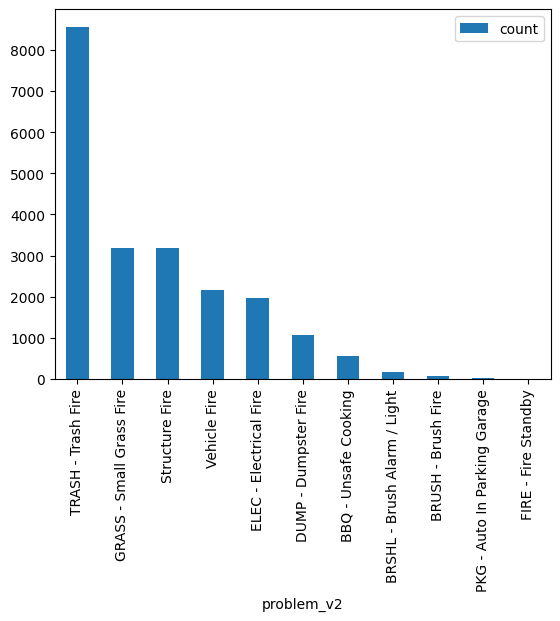

In [17]:
incidents['problem_v2'] = incidents['problem'].apply(lambda x: 'Vehicle Fire' if x == 'AUTO - Auto Fire' else 'Structure Fire' if x[0:3] == "BOX" else x)

incidents.groupby("problem_v2").size().reset_index(name="count").sort_values("count", ascending=False).plot(kind="bar", x="problem_v2")

<Axes: xlabel='longitude', ylabel='latitude'>

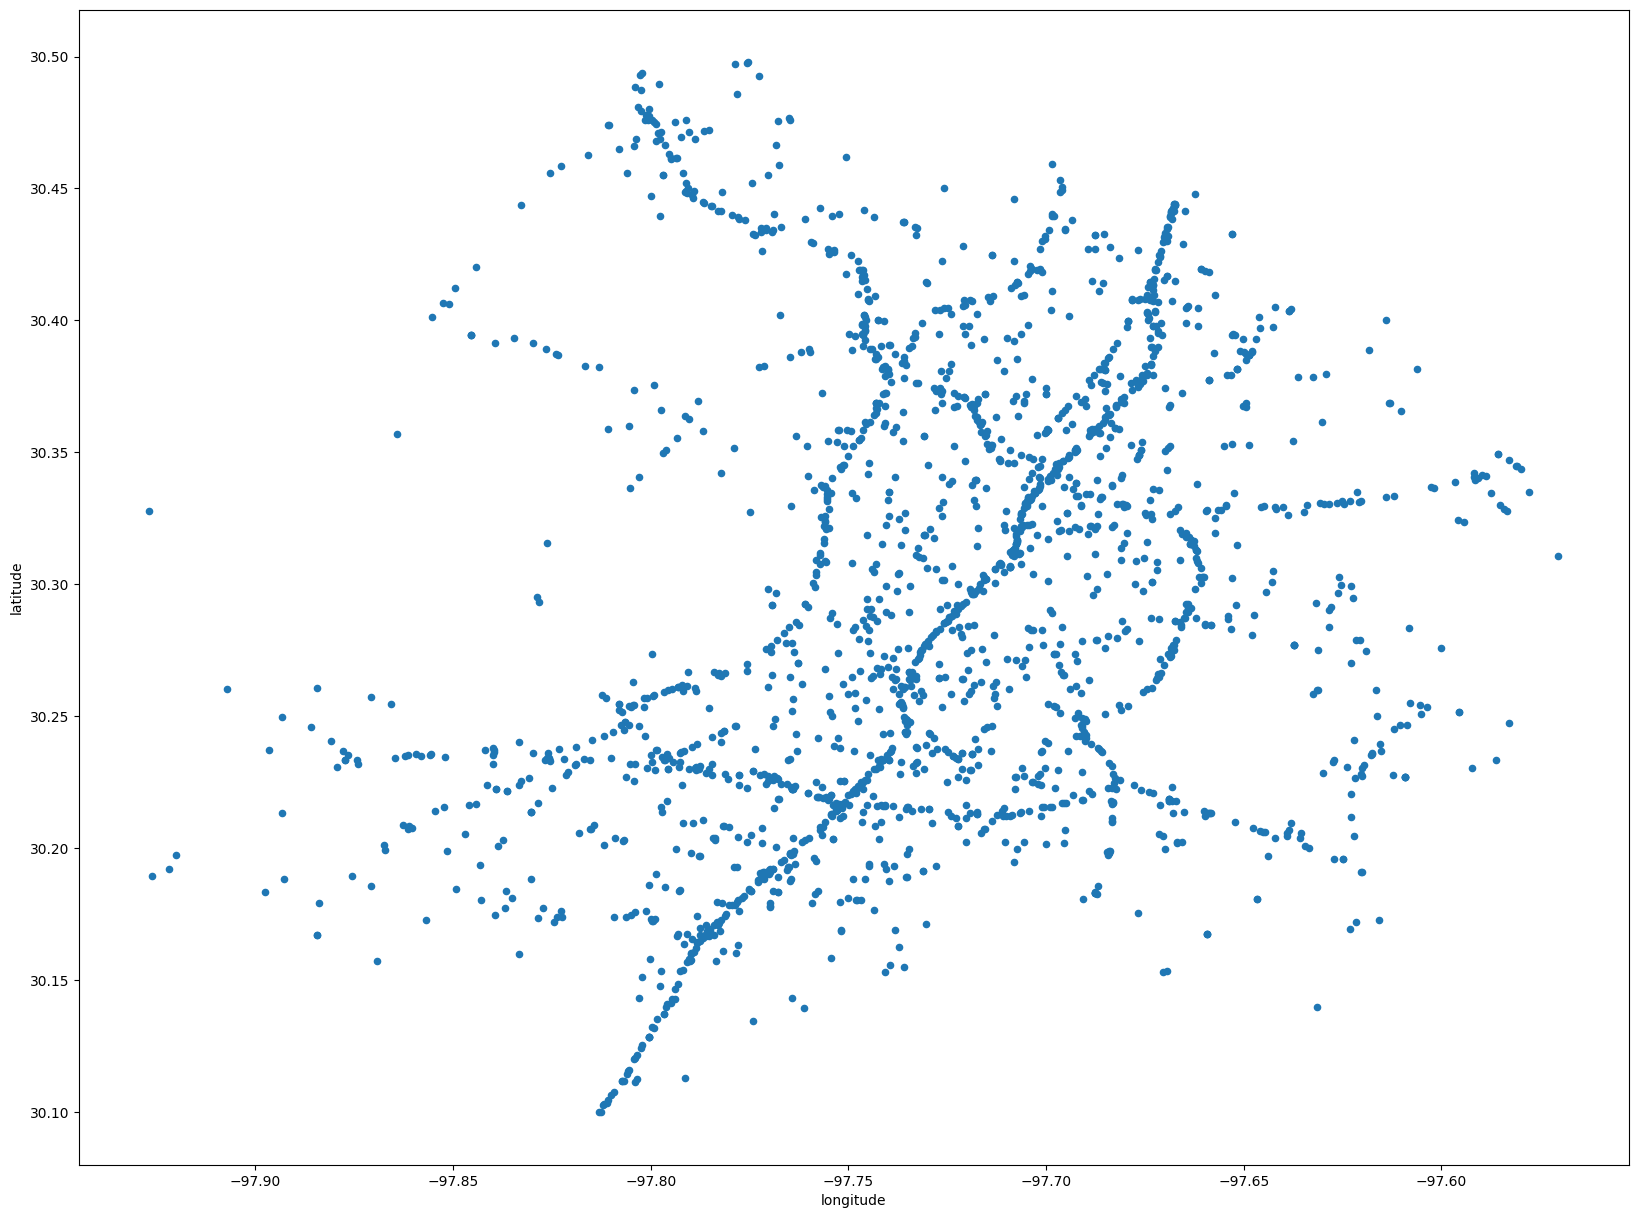

In [18]:
vehicles.plot.scatter(x="longitude", y="latitude", figsize=(20,15))